In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!unzip /content/drive/MyDrive/Data/GeneHist.zip -d /content/

Archive:  /content/drive/MyDrive/Data/GeneHist.zip
 extracting: /content/TCGA-BRCA-A2-DEEPMED-TILES.zip  
 extracting: /content/TCGA-BRCA-A2-CLINI.xlsx  
 extracting: /content/TCGA-BRCA-A2_SLIDE.xlsx  
 extracting: /content/TCGA-BRCA-RNA-Seq.csv  
 extracting: /content/TCGA-BRCA-A2-target_variable.xlsx  


In [3]:
!unzip -q /content/TCGA-BRCA-A2-DEEPMED-TILES.zip -d /content/


In [4]:
import random
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torchvision.transforms as transforms
import seaborn as sns
from PIL import Image
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization, MultiHeadAttention,
    LayerNormalization, Add, GlobalAveragePooling2D,
    GlobalAveragePooling1D, Concatenate, Reshape # Added Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, precision_recall_curve, auc, accuracy_score
import csv
import gc # Kept gc for memory management

In [5]:
# Set random seed for reproducibility
random.seed(39)
tf.random.set_seed(39)
np.random.seed(39)

In [6]:
# Correcting target class from tab-delimited to comma-delimited
input_file = '/content/TCGA-BRCA-RNA-Seq.csv'
output_file = '/content/output.csv'

In [7]:
with open(input_file, 'r', newline='', encoding='utf-8') as infile:
    reader = csv.reader(infile)
    with open(output_file, 'w', newline='', encoding='utf-8') as outfile_csv:
        writer = csv.writer(outfile_csv)
        for row in reader:
            new_row = []
            for cell in row:
                new_row.extend(cell.split('\t'))
            writer.writerow(new_row)

# Filter out rows with zero values from gene expression data
filtered_output_file = '/content/gene_expression.csv'
with open(output_file, 'r', newline='', encoding='utf-8') as outfile_csv_read:
    reader = csv.reader(outfile_csv_read)
    with open(filtered_output_file, 'w', newline='', encoding='utf-8') as filtered_outfile:
        writer = csv.writer(filtered_outfile)
        header = next(reader, None)
        if header:
            writer.writerow(header)
        for row in reader:
            if not all(cell == '0.0' for cell in row[1:]):
                writer.writerow(row)

print(f"Transformation complete. Output saved to '{output_file}'.")
print(f"Filtered output saved to '{filtered_output_file}'.")


Transformation complete. Output saved to '/content/output.csv'.
Filtered output saved to '/content/gene_expression.csv'.


In [8]:
# Define input files and paths
GEX_FILE = "/content/gene_expression.csv"
METADATA_FILE = "/content/TCGA-BRCA-A2-target_variable.xlsx"
IMAGE_DIR = "/content/BLOCKS_NORM_MACENKO"

In [9]:
# --- DATA PREPROCESSING FUNCTIONS ---
def preprocess_metadata(file_path):
    try:
        metadata = pd.read_excel(file_path)
    except FileNotFoundError:
        print(f"Error: Metadata file {file_path} not found.")
        return pd.DataFrame()

    if 'TCGA Subtype' not in metadata.columns or 'Sample ID' not in metadata.columns:
        print("Error: Metadata file must contain 'TCGA Subtype' and 'Sample ID' columns.")
        return pd.DataFrame()

    metadata = metadata[metadata['TCGA Subtype'] != 'BRCA.Normal']
    metadata['TCGA Subtype'] = metadata['TCGA Subtype'].replace({
        'BRCA.LumA': 0, 'BRCA.LumB': 0,
        'BRCA.Basal': 1, 'BRCA.Her2': 1
    })
    metadata = metadata[pd.to_numeric(metadata['TCGA Subtype'], errors='coerce').notnull()]
    metadata['TCGA Subtype'] = metadata['TCGA Subtype'].astype(int)
    return metadata.reset_index(drop=True)

def preprocess_images(image_dir, metadata, max_patches=50, img_size=(256, 256)):
    patch_data = {}
    valid_sample_ids = []
    color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)

    if not os.path.isdir(image_dir):
        print(f"Error: Image directory '{image_dir}' not found or is not a directory.")
        return {}, metadata

    for patient_id in metadata['Sample ID'].values:
        try:
            sample_id_matches = [item for item in os.listdir(image_dir) if patient_id in item and os.path.isdir(os.path.join(image_dir, item))]

            if not sample_id_matches:
                continue

            patient_path = os.path.join(image_dir, sample_id_matches[0])

            img_files = [f for f in os.listdir(patient_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
            if len(img_files) == 0:
                continue

            if len(img_files) > max_patches:
                selected_files = random.sample(img_files, max_patches)
            else:
                selected_files = img_files

            patches = []
            for img_file in selected_files:
                img_path = os.path.join(patient_path, img_file)
                try:
                    with Image.open(img_path) as img:
                        if img.mode != 'RGB':
                            img = img.convert('RGB')
                        patch = img.resize(img_size)
                        patch_tensor = transforms.ToTensor()(patch)
                        patch_tensor = color_jitter(patch_tensor)
                        patch_array = patch_tensor.numpy().transpose(1, 2, 0)
                        patch_array = np.clip(patch_array, 0, 1)
                        patches.append(patch_array)
                except FileNotFoundError:
                    # print(f"Image file not found: {img_path}") # Can be verbose
                    continue
                except Exception as e:
                    # print(f"Error processing image {img_path}: {e}") # Can be verbose
                    continue

            if len(patches) > 0:
                while len(patches) < max_patches and len(patches) > 0: # Check len(patches) > 0 to avoid infinite loop on empty patches
                    patches.append(patches[random.randint(0, len(patches)-1)])

                if len(patches) == max_patches:
                    patch_data[patient_id] = np.array(patches)
                    valid_sample_ids.append(patient_id)

        except Exception as e:
            print(f"General error processing patient {patient_id}: {e}")
            continue

    updated_metadata = metadata[metadata['Sample ID'].isin(valid_sample_ids)].copy().reset_index(drop=True)
    final_patch_data = {sample_id: patch_data[sample_id] for sample_id in updated_metadata['Sample ID'] if sample_id in patch_data}
    return final_patch_data, updated_metadata

def filter_data(gex_file_path, metadata):
    if metadata.empty:
        print("Metadata is empty, cannot filter GEX data.")
        return pd.DataFrame(), pd.DataFrame(), pd.Series(dtype='int')

    sample_ids_metadata = metadata['Sample ID'].tolist()

    try:
        gex_data = pd.read_csv(gex_file_path, index_col=0)
    except FileNotFoundError:
        print(f"Error: Gene expression file '{gex_file_path}' not found.")
        return pd.DataFrame(), metadata, pd.Series(dtype='int')
    except pd.errors.EmptyDataError:
        print(f"Error: Gene expression file '{gex_file_path}' is empty.")
        return pd.DataFrame(), metadata, pd.Series(dtype='int')
    except ValueError as e:
        print(f"Error reading GEX file (check if first column is gene names/IDs): {e}")
        return pd.DataFrame(), metadata, pd.Series(dtype='int')

    if gex_data.empty:
        print("GEX data is empty after loading.")
        return pd.DataFrame(), metadata, pd.Series(dtype='int')

    gex_data = gex_data.transpose()

    common_ids = list(set(sample_ids_metadata) & set(gex_data.index))

    if not common_ids:
        print("No common sample IDs found between metadata and GEX data.")
        return pd.DataFrame(), metadata, pd.Series(dtype='int')

    metadata_filtered = metadata[metadata['Sample ID'].isin(common_ids)].copy()
    metadata_filtered = metadata_filtered.sort_values(by='Sample ID').reset_index(drop=True)

    ordered_sample_ids = metadata_filtered['Sample ID'].tolist()
    filtered_gex = gex_data.loc[ordered_sample_ids]

    labels = metadata_filtered['TCGA Subtype']

    return filtered_gex.reset_index(drop=True), metadata_filtered, labels.reset_index(drop=True)


def preprocess_gene_expression(gex_data, nan_strategy='mean', normalization='zscore'):
    if gex_data.empty:
        print("Warning: GEX data is empty before preprocessing. Returning as is.")
        return gex_data

    gex_data = gex_data.apply(pd.to_numeric, errors='coerce')

    min_val = gex_data.min().min()
    if pd.isna(min_val): # All values became NaN after to_numeric
        print("Warning: All GEX data became NaN after trying to convert to numeric. Filling with 0.")
        return gex_data.fillna(0)

    if min_val <= 0:
        gex_data = gex_data - min_val + 1e-9 # Shift to be positive for log

    gex_data = np.log1p(gex_data)

    if normalization == 'zscore': scaler = StandardScaler()
    elif normalization == 'minmax': scaler = MinMaxScaler()
    else:
        print("No normalization applied to GEX data beyond log transform.")
        return gex_data.copy() # Return a copy to avoid modifying original if no scaling

    gex_data_scaled_np = scaler.fit_transform(gex_data)
    gex_data_scaled = pd.DataFrame(gex_data_scaled_np, index=gex_data.index, columns=gex_data.columns)

    if gex_data_scaled.isnull().values.any():
        print(f"NaNs found after scaling. Imputing with '{nan_strategy}'.")
        if nan_strategy == 'mean': gex_data_scaled = gex_data_scaled.fillna(gex_data_scaled.mean())
        elif nan_strategy == 'median': gex_data_scaled = gex_data_scaled.fillna(gex_data_scaled.median())
        elif nan_strategy == 'drop_genes': gex_data_scaled = gex_data_scaled.dropna(axis=1)
        elif nan_strategy == 'drop_samples': gex_data_scaled = gex_data_scaled.dropna(axis=0)
        gex_data_scaled = gex_data_scaled.fillna(0) # Fallback for any remaining NaNs

    return gex_data_scaled

def extract_image_features(image_data_list):
    patient_data = []
    if not image_data_list:
        print("No image data provided to extract_image_features.")
        return np.array([])

    # Validate that all items are 4D numpy arrays with at least one patch
    if not all(isinstance(item, np.ndarray) and item.ndim == 4 and item.shape[0] > 0 for item in image_data_list):
        print("Warning: Some items in image_data_list are not valid 4D numpy arrays or are empty.")
        # Filter out invalid items
        image_data_list = [item for item in image_data_list if isinstance(item, np.ndarray) and item.ndim == 4 and item.shape[0] > 0]
        if not image_data_list: # If all were invalid
            return np.array([])

    first_item_shape = image_data_list[0].shape
    input_shape_cnn = first_item_shape[1:] # (H, W, C)
    num_patches_per_patient = first_item_shape[0]

    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape_cnn)
    x = GlobalAveragePooling2D()(base_model.output)
    feature_extractor = Model(inputs=base_model.input, outputs=x)

    for image_patches_for_patient in image_data_list:
        # Ensure consistent shape for each patient's patches
        if image_patches_for_patient.shape[0] != num_patches_per_patient or \
           image_patches_for_patient.shape[1:] != input_shape_cnn :
             print(f"Warning: Inconsistent patch array shape {image_patches_for_patient.shape} for a patient. Expected ({num_patches_per_patient},{input_shape_cnn}). Appending zeros.")
             # Append zeros matching expected feature dim (2048 for ResNet50 default)
             patient_data.append(np.zeros((num_patches_per_patient, 2048))) # ResNet50 GAP output is 2048
             continue

        all_patch_features = np.zeros((num_patches_per_patient, 2048)) # ResNet50 GAP output is 2048
        batch_size_cnn = 16 # Process patches in batches
        for i in range(0, num_patches_per_patient, batch_size_cnn):
            batch = image_patches_for_patient[i:i+batch_size_cnn]
            if batch.shape[0] > 0: # Ensure batch is not empty
                 all_patch_features[i:i+batch_size_cnn] = feature_extractor.predict(batch, verbose=0)

        patient_data.append(all_patch_features)

    if not patient_data: # If loop resulted in no data (e.g., all were inconsistent shapes)
        return np.array([])
    return np.array(patient_data)

In [10]:
# --- MODEL ARCHITECTURE ---
def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(inputs, inputs)
    attention_output = Add()([inputs, attention_output]) # Residual
    attention_output = LayerNormalization(epsilon=1e-6)(attention_output)
    # Feed Forward Part
    ffn_output = Dense(ff_dim, activation="gelu")(attention_output)
    ffn_output = Dropout(dropout)(ffn_output)
    ffn_output = Dense(inputs.shape[-1])(ffn_output) # Project back to input dim
    ffn_output = Add()([attention_output, ffn_output]) # Residual
    sequence_output = LayerNormalization(epsilon=1e-6)(ffn_output)
    return sequence_output

def bidirectional_cross_modal_attention(vision_features, gene_features, num_heads=8, key_dim=64):
    projection_dim = key_dim * num_heads

    # Project vision and gene features to a common dimension for attention
    vision_projected = Dense(projection_dim, name='vision_projection_bcma')(vision_features)
    gene_projected = Dense(projection_dim, name='gene_projection_bcma')(gene_features)

    # Vision to Gene Attention
    v2g_attention_layer = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, name='v2g_attention')
    v2g_attention_out = v2g_attention_layer(query=vision_projected, key=gene_projected, value=gene_projected)
    vision_attended = Add(name='v2g_add')([vision_projected, v2g_attention_out])
    vision_attended = LayerNormalization(epsilon=1e-6, name='v2g_layernorm')(vision_attended)

    # Gene to Vision Attention
    g2v_attention_layer = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, name='g2v_attention')
    g2v_attention_out = g2v_attention_layer(query=gene_projected, key=vision_projected, value=vision_projected)
    gene_attended = Add(name='g2v_add')([gene_projected, g2v_attention_out])
    gene_attended = LayerNormalization(epsilon=1e-6, name='g2v_layernorm')(gene_attended)

    return vision_attended, gene_attended

def build_transformer_model(gene_dims, vision_feature_dim=2048, num_patches=50, num_heads=8, ff_dim=512, num_transformer_blocks=2):
    # Inputs
    vision_input = Input(shape=(num_patches, vision_feature_dim), name="vision_features")
    gene_input = Input(shape=(gene_dims,), name="gene_features")

    # Gene features processing
    gene_dense_1_dim = 512 # Dimension after first dense layer for genes
    gene_features_processed = Dense(gene_dense_1_dim, activation="gelu", name="gene_dense_1")(gene_input)
    gene_features_processed = BatchNormalization(name="gene_bn_1")(gene_features_processed)
    gene_features_processed = Dropout(0.3, name="gene_dropout_1")(gene_features_processed)
    # Expand dims for gene features to be (batch, 1, gene_dense_1_dim) for attention
    gene_features_expanded = Reshape((1, gene_dense_1_dim), name="gene_expand_dims")(gene_features_processed)

    # Vision features processing (self-attention through Transformer Encoders)
    vision_features_processed = vision_input
    for i in range(num_transformer_blocks):
        # Calculate head_size for self-attention dynamically or use a fixed reasonable value
        self_attn_head_size = vision_feature_dim // num_heads if vision_feature_dim % num_heads == 0 else 64 # Default if not divisible
        vision_features_processed = transformer_encoder_block(
            vision_features_processed, head_size=self_attn_head_size, num_heads=num_heads,
            ff_dim=ff_dim, dropout=0.2, # Renamed ff_dim variable in TEB for clarity
        )

    # Bidirectional Cross-Modal Attention
    # Key dimension for cross-attention, can be different from self-attention head_size
    key_dim_cross_attn = 64
    vision_attended, gene_attended = bidirectional_cross_modal_attention(
        vision_features_processed, gene_features_expanded, num_heads=num_heads, key_dim=key_dim_cross_attn
    )

    # The output dimension of gene_attended will be num_heads * key_dim_cross_attn
    gene_attended_feature_dim = key_dim_cross_attn * num_heads

    # Pooling and Squeezing
    vision_pooled = GlobalAveragePooling1D(name="vision_avg_pool")(vision_attended)
    # gene_attended is (batch, 1, gene_attended_feature_dim), squeeze to (batch, gene_attended_feature_dim)
    gene_features_squeezed = Reshape((gene_attended_feature_dim,), name="gene_squeeze")(gene_attended)


    # Concatenate modalities
    combined = Concatenate(name="combine_modalities")([vision_pooled, gene_features_squeezed])

    # Final Classifier MLP
    x = Dense(512, activation="gelu", kernel_regularizer=l2(1e-4), name="combined_dense_1")(combined)
    x = BatchNormalization(name="combined_bn_1")(x)
    x = Dropout(0.5, name="combined_dropout_1")(x)
    x = Dense(256, activation="gelu", kernel_regularizer=l2(1e-4), name="combined_dense_2")(x)
    x = Dropout(0.3, name="combined_dropout_2")(x)
    output = Dense(1, activation="sigmoid", name="prediction_output")(x)

    model = Model(inputs=[vision_input, gene_input], outputs=output, name="multimodal_model")
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [11]:
# --- LEARNING RATE AND TRAINING PLOT FUNCTIONS ---
def lr_scheduler(epoch, lr):
    if epoch < 10: return lr
    else: return lr * float(tf.math.exp(-0.1))

def plot_training_curves(all_histories, metric_name='accuracy', val_metric_name='val_accuracy'):
    """
    Modern, visually impressive training curves visualization with dark theme,
    glassmorphism effects, and smooth gradients.
    """
    if not all_histories:
        print("No history objects to plot.")
        return

    epochs_per_fold = [len(hist.history['loss']) for hist in all_histories if hist and 'loss' in hist.history]
    if not epochs_per_fold:
        print("No valid history data found.")
        return

    min_epochs = min(epochs_per_fold)

    # Extract training data
    all_train_loss = [hist.history['loss'][:min_epochs] for hist in all_histories
                      if hist and 'loss' in hist.history and len(hist.history['loss']) >= min_epochs]
    all_val_loss = [hist.history['val_loss'][:min_epochs] for hist in all_histories
                    if hist and 'val_loss' in hist.history and len(hist.history['val_loss']) >= min_epochs]
    all_train_accuracy = [hist.history[metric_name][:min_epochs] for hist in all_histories
                          if hist and metric_name in hist.history and len(hist.history[metric_name]) >= min_epochs]
    all_val_accuracy = [hist.history[val_metric_name][:min_epochs] for hist in all_histories
                        if hist and val_metric_name in hist.history and len(hist.history[val_metric_name]) >= min_epochs]

    if not all_train_loss or not all_val_loss or not all_train_accuracy or not all_val_accuracy:
        print("Could not gather sufficient history data for plotting averages.")
        return

    # Calculate statistics
    avg_train_loss, std_train_loss = np.mean(all_train_loss, axis=0), np.std(all_train_loss, axis=0)
    avg_val_loss, std_val_loss = np.mean(all_val_loss, axis=0), np.std(all_val_loss, axis=0)
    avg_train_accuracy, std_train_accuracy = np.mean(all_train_accuracy, axis=0), np.std(all_train_accuracy, axis=0)
    avg_val_accuracy, std_val_accuracy = np.mean(all_val_accuracy, axis=0), np.std(all_val_accuracy, axis=0)
    epochs_range = range(1, min_epochs + 1)

    # Modern dark theme with glassmorphism
    plt.style.use('dark_background')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.patch.set_facecolor('#0a0a0a')

    # Define modern color palette with gradients
    colors = {
        'train': {'main': '#00D2FF', 'gradient': '#3A7BD5', 'fill': '#00D2FF'},
        'val': {'main': '#FF6B6B', 'gradient': '#FF8E53', 'fill': '#FF6B6B'}
    }

    # Loss subplot with modern styling
    ax1.set_facecolor('#111111')
    ax1.grid(True, alpha=0.15, linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)

    # Create gradient-like effect with multiple line segments
    for i in range(len(epochs_range)-1):
        alpha_grad = 0.8 + 0.2 * (i / len(epochs_range))
        ax1.plot(epochs_range[i:i+2], avg_train_loss[i:i+2],
                color=colors['train']['main'], linewidth=3, alpha=alpha_grad)
        ax1.plot(epochs_range[i:i+2], avg_val_loss[i:i+2],
                color=colors['val']['main'], linewidth=3, alpha=alpha_grad)

    # Confidence intervals with glassmorphism effect
    ax1.fill_between(epochs_range, avg_train_loss - std_train_loss, avg_train_loss + std_train_loss,
                     color=colors['train']['fill'], alpha=0.2, linewidth=0)
    ax1.fill_between(epochs_range, avg_val_loss - std_val_loss, avg_val_loss + std_val_loss,
                     color=colors['val']['fill'], alpha=0.2, linewidth=0)

    # Enhanced styling for loss plot
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold', color='#FFFFFF')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold', color='#FFFFFF')
    ax1.set_title('Training & Validation Loss', fontsize=16, fontweight='bold',
                  color='#FFFFFF', pad=20)

    # Custom legend with modern styling
    train_line = plt.Line2D([0], [0], color=colors['train']['main'], linewidth=3, label='Training')
    val_line = plt.Line2D([0], [0], color=colors['val']['main'], linewidth=3, label='Validation')
    ax1.legend(handles=[train_line, val_line], loc='upper right', frameon=True,
               fancybox=True, shadow=True, framealpha=0.3, facecolor='#222222')

    # Accuracy subplot with matching styling
    ax2.set_facecolor('#111111')
    ax2.grid(True, alpha=0.15, linestyle='-', linewidth=0.5)
    ax2.set_axisbelow(True)

    # Gradient effect for accuracy
    for i in range(len(epochs_range)-1):
        alpha_grad = 0.8 + 0.2 * (i / len(epochs_range))
        ax2.plot(epochs_range[i:i+2], avg_train_accuracy[i:i+2],
                color=colors['train']['main'], linewidth=3, alpha=alpha_grad)
        ax2.plot(epochs_range[i:i+2], avg_val_accuracy[i:i+2],
                color=colors['val']['main'], linewidth=3, alpha=alpha_grad)

    # Confidence intervals
    ax2.fill_between(epochs_range, avg_train_accuracy - std_train_accuracy,
                     avg_train_accuracy + std_train_accuracy,
                     color=colors['train']['fill'], alpha=0.2, linewidth=0)
    ax2.fill_between(epochs_range, avg_val_accuracy - std_val_accuracy,
                     avg_val_accuracy + std_val_accuracy,
                     color=colors['val']['fill'], alpha=0.2, linewidth=0)

    # Enhanced styling for accuracy plot
    ax2.set_xlabel('Epochs', fontsize=12, fontweight='bold', color='#FFFFFF')
    ax2.set_ylabel(metric_name.capitalize(), fontsize=12, fontweight='bold', color='#FFFFFF')
    ax2.set_title(f'Training & Validation {metric_name.capitalize()}', fontsize=16,
                  fontweight='bold', color='#FFFFFF', pad=20)

    # Custom legend for accuracy
    ax2.legend(handles=[train_line, val_line], loc='lower right', frameon=True,
               fancybox=True, shadow=True, framealpha=0.3, facecolor='#222222')

    # Add performance highlights
    best_train_acc = np.max(avg_train_accuracy)
    best_val_acc = np.max(avg_val_accuracy)
    best_train_epoch = np.argmax(avg_train_accuracy) + 1
    best_val_epoch = np.argmax(avg_val_accuracy) + 1

    # Highlight best points with glowing effects
    ax2.scatter(best_train_epoch, best_train_acc, color=colors['train']['main'],
               s=100, zorder=5, edgecolor='white', linewidth=2, alpha=0.9)
    ax2.scatter(best_val_epoch, best_val_acc, color=colors['val']['main'],
               s=100, zorder=5, edgecolor='white', linewidth=2, alpha=0.9)

    # Add subtle glow effect around best points
    ax2.scatter(best_train_epoch, best_train_acc, color=colors['train']['main'],
               s=300, alpha=0.1, zorder=4)
    ax2.scatter(best_val_epoch, best_val_acc, color=colors['val']['main'],
               s=300, alpha=0.1, zorder=4)

    # Modern typography and spacing
    plt.suptitle('Model Training Performance Analysis', fontsize=20, fontweight='bold',
                 color='#FFFFFF', y=0.98)

    # Adjust layout with modern spacing
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Add subtle border glow effect
    for spine in ax1.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1.5)
    for spine in ax2.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1.5)

    # Save with high quality
    filename = 'training_curves_modern_analysis.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='#0a0a0a',
                edgecolor='none', pad_inches=0.2)

    print(f"Saved modern training curves visualization to {filename}")
    plt.show()

    # Reset to default style to avoid affecting other plots
    plt.style.use('default')

In [12]:
# --- START: NEW XAI CODE ---
class MultimodalExplainer:
    def __init__(self, model, gene_feature_names):
        self.model = model
        self.gene_feature_names = gene_feature_names if gene_feature_names is not None else []

    def integrated_gradients(self, inputs, baseline=None, steps=50):
        """
        Compute Integrated Gradients for multimodal inputs
        Most reliable and publication-ready XAI method
        """
        if not isinstance(inputs, list):
            inputs = [inputs]

        if baseline is None:
            baseline = [tf.zeros_like(inp, dtype=tf.float32) for inp in inputs]
        elif not isinstance(baseline, list):
            baseline = [tf.constant(baseline, dtype=tf.float32) if not hasattr(baseline, 'shape') else tf.cast(baseline, tf.float32)] * len(inputs)


        # Ensure inputs and baselines are float32, as required by GradientTape with some models/layers
        inputs = [tf.cast(inp, tf.float32) for inp in inputs]
        baseline = [tf.cast(b, tf.float32) for b in baseline]

        alphas = tf.linspace(0.0, 1.0, steps + 1)
        gradients_accumulated = [tf.zeros_like(inp, dtype=tf.float32) for inp in inputs]

        for alpha in alphas:
            interpolated_inputs = []
            for i in range(len(inputs)):
                interpolated_val = baseline[i] + alpha * (inputs[i] - baseline[i])
                interpolated_inputs.append(interpolated_val)

            with tf.GradientTape() as tape:
                tape.watch(interpolated_inputs)
                predictions = self.model(interpolated_inputs, training=False) # Ensure model is in inference mode
            grads = tape.gradient(predictions, interpolated_inputs)

            if grads is not None and all(g is not None for g in grads):
                for i in range(len(inputs)):
                    gradients_accumulated[i] += grads[i]
            else:
                print(f"Warning: Grads are None for alpha={alpha}. This might indicate issues with differentiation.")
                # If any grad is None, we might return zeros or raise error
                # For now, we skip adding to accumulator for this step
                # return [tf.zeros_like(inp) for inp in inputs] # Option: return zeros

        # Average gradients
        integrated_grads = []
        for i in range(len(inputs)):
            avg_grad = gradients_accumulated[i] / float(steps + 1)
            ig = (inputs[i] - baseline[i]) * avg_grad
            integrated_grads.append(ig)

        return integrated_grads


    def extract_attention_weights(self, inputs):
        """
        Extract attention weights from transformer layers
        Perfect for your architecture - shows cross-modal attention
        """
        if not isinstance(inputs, list): # Ensure inputs is a list
            inputs = [inputs]
        inputs = [tf.cast(inp, tf.float32) for inp in inputs] # Ensure float32

        attention_layers_outputs = []
        attention_layer_names = []

        # Iterate through layers to find MultiHeadAttention layers
        for layer in self.model.layers:
            if isinstance(layer, tf.keras.layers.MultiHeadAttention):
                attention_layers_outputs.append(layer.output) # This is the context vector
                attention_layer_names.append(layer.name)
            # For layers that wrap MHA (like custom transformer blocks), need more specific logic
            # The current TEB directly uses MHA, so its output is just the sequence_output
            # The BCSA layer uses MHA layers named 'v2g_attention' and 'g2v_attention'
            if 'v2g_attention' in layer.name or 'g2v_attention' in layer.name:
                 attention_layers_outputs.append(layer.output)
                 attention_layer_names.append(layer.name)

        # Fallback: if no MHA layers found, try layers with 'attention' in name
        if not attention_layers_outputs:
            for layer in self.model.layers:
                if 'attention' in layer.name.lower(): # Catches MHA layers by name convention
                    attention_layers_outputs.append(layer.output)
                    attention_layer_names.append(layer.name)

        if not attention_layers_outputs:
            print("No suitable attention layers found or accessible for weight extraction.")
            return None
        try:
            attention_model = tf.keras.Model(
                inputs=self.model.inputs,
                outputs=attention_layers_outputs
            )
            print(f"Extracting outputs from attention layers: {attention_layer_names}")
            attention_values = attention_model(inputs, training=False)
        except Exception as e:
            print(f"Error creating or calling attention_model: {e}")
            return None

        if not isinstance(attention_values, list):
            attention_values = [attention_values] # Make it a list for consistency

        return attention_values


    def compute_gene_importance(self, vision_data, gene_data, labels, method='permutation', max_genes_to_permute=None): # MODIFIED
        """
        Compute gene feature importance using permutation.
        If max_genes_to_permute is set, a random subset of genes is chosen.
        """
        vision_data_tf = tf.cast(vision_data, tf.float32)
        gene_data_tf = tf.cast(gene_data, tf.float32)
        labels_tf = tf.cast(labels, tf.int32)

        baseline_metrics = self.model.evaluate([vision_data_tf, gene_data_tf], labels_tf, verbose=0)
        baseline_acc = baseline_metrics[1]

        num_total_genes = gene_data_tf.shape[1]
        importances = np.zeros(num_total_genes) # Initialize with zeros for all genes

        original_gene_data_np = gene_data_tf.numpy()

        if max_genes_to_permute is not None and 0 < max_genes_to_permute < num_total_genes:
            gene_indices_to_permute = np.random.choice(num_total_genes, max_genes_to_permute, replace=False)
            print(f"Computing permutation importance for a random subset of {max_genes_to_permute}/{num_total_genes} genes...")
        else:
            gene_indices_to_permute = np.arange(num_total_genes)
            if max_genes_to_permute is not None and max_genes_to_permute >= num_total_genes:
                print(f"max_genes_to_permute ({max_genes_to_permute}) >= total genes ({num_total_genes}). Permuting all genes.")
            elif max_genes_to_permute is None:
                 print(f"Computing permutation importance for all {num_total_genes} genes...")
            # If max_genes_to_permute is 0 or negative, it will effectively permute all genes due to np.arange behavior
            # or could be handled explicitly if needed.


        processed_count = 0
        for i in gene_indices_to_permute: # Iterate over selected (or all) gene indices
            corrupted_gene_data_np = original_gene_data_np.copy()
            np.random.shuffle(corrupted_gene_data_np[:, i]) # Shuffle column i (the selected gene)

            corrupted_gene_data_tf = tf.convert_to_tensor(corrupted_gene_data_np, dtype=tf.float32)

            corrupted_metrics = self.model.evaluate(
                [vision_data_tf, corrupted_gene_data_tf], labels_tf, verbose=0
            )
            corrupted_acc = corrupted_metrics[1]

            importance_score = baseline_acc - corrupted_acc
            importances[i] = importance_score # Store importance at the correct original gene index

            processed_count += 1
            # Adjust print frequency to be less overwhelming if many genes are selected
            if processed_count % 50 == 0 or processed_count == len(gene_indices_to_permute):
                print(f"Processed {processed_count}/{len(gene_indices_to_permute)} selected genes for permutation importance.")

        return importances


    def gradcam_patches(self, vision_data, gene_data, target_layer_name=None, target_input_index=0):
        """
        Compute GradCAM for histology patches.
        target_input_index: 0 for vision, 1 for gene, if model has multiple inputs
                           and target_layer is specific to one branch before fusion.
        """
        vision_data_tf = tf.cast(vision_data, tf.float32)
        gene_data_tf = tf.cast(gene_data, tf.float32)

        if target_layer_name is None:
            suitable_layer_found = False
            for layer in reversed(self.model.layers):
                if len(layer.output_shape) == 3 and layer.output_shape[1] == vision_data_tf.shape[1]: # (batch, num_patches, D)
                    if 'vision' in layer.name.lower() or 'v2g' in layer.name.lower() or \
                       (hasattr(layer, '_name') and 'transformer_encoder' in layer._name.lower() and 'layernorm' in layer.name.lower()): # Heuristic
                        target_layer_name = layer.name
                        print(f"Auto-selected GradCAM target layer: {target_layer_name}")
                        suitable_layer_found = True
                        break
            if not suitable_layer_found:
                print("Could not automatically find a suitable layer for GradCAM on patches. Please specify target_layer_name.")
                return None
        else:
            try:
                _ = self.model.get_layer(target_layer_name) # Check if layer exists
            except ValueError:
                print(f"Error: Specified target_layer_name '{target_layer_name}' not found in the model.")
                return None

        grad_model = tf.keras.models.Model(
            inputs=self.model.inputs,
            outputs=[self.model.get_layer(target_layer_name).output, self.model.output]
        )

        with tf.GradientTape() as tape:
            model_inputs = [vision_data_tf, gene_data_tf]
            conv_outputs, predictions = grad_model(model_inputs, training=False)
            loss = predictions[:, 0]

        grads = tape.gradient(loss, conv_outputs)

        if grads is None:
            print("Error: Gradients for GradCAM are None. Check model differentiability or target layer.")
            return None

        patch_importance = tf.reduce_sum(tf.abs(grads), axis=-1)
        max_val = tf.reduce_max(patch_importance, axis=1, keepdims=True)
        min_val = tf.reduce_min(patch_importance, axis=1, keepdims=True)
        patch_importance_normalized = (patch_importance - min_val) / (max_val - min_val + 1e-6)

        return patch_importance_normalized.numpy()



    def gradcam_patches(self, vision_data, gene_data, target_layer_name=None, target_input_index=0):
      """
      Compute GradCAM for histology patches.
      target_input_index: 0 for vision, 1 for gene, if model has multiple inputs
                        and target_layer is specific to one branch before fusion.
      """
      vision_data_tf = tf.cast(vision_data, tf.float32)
      gene_data_tf = tf.cast(gene_data, tf.float32)

      if target_layer_name is None:
          suitable_layer_found = False
          for layer in reversed(self.model.layers):
              try:
                  # Get output shape safely - try multiple approaches
                  output_shape = None

                  # Method 1: Direct output_shape attribute
                  if hasattr(layer, 'output_shape') and layer.output_shape is not None:
                      output_shape = layer.output_shape

                  # Method 2: Through output tensor shape
                  elif hasattr(layer, 'output') and layer.output is not None:
                      if hasattr(layer.output, 'shape'):
                          output_shape = layer.output.shape.as_list()

                  # Method 3: Use compute_output_shape with sample input
                  elif hasattr(layer, 'compute_output_shape'):
                      try:
                          # For vision layers, use vision input shape
                          if 'vision' in layer.name.lower() or 'v2g' in layer.name.lower():
                              sample_input_shape = vision_data_tf.shape
                          else:
                              # Try with vision shape first, then gene shape
                              sample_input_shape = vision_data_tf.shape
                          output_shape = layer.compute_output_shape(sample_input_shape)
                          if hasattr(output_shape, 'as_list'):
                              output_shape = output_shape.as_list()
                      except:
                          continue

                  # Skip if we couldn't get the output shape
                  if output_shape is None:
                      continue

                  # Check if it's a 3D tensor with matching patch dimension
                  if (len(output_shape) >= 3 and
                      output_shape[1] is not None and
                      output_shape[1] == vision_data_tf.shape[1]):  # (batch, num_patches, D)

                      # Look for layers that are likely vision-related
                      layer_name_lower = layer.name.lower()
                      if (any(keyword in layer_name_lower for keyword in
                            ['vision', 'v2g', 'transformer', 'attention', 'layernorm']) and
                          'gene' not in layer_name_lower):
                          target_layer_name = layer.name
                          print(f"Auto-selected GradCAM target layer: {target_layer_name} (shape: {output_shape})")
                          suitable_layer_found = True
                          break

              except Exception as e:
                  # Skip layers that cause any issues
                  continue

          if not suitable_layer_found:
              print("Could not automatically find a suitable layer for GradCAM on patches. Please specify target_layer_name.")
              return None
      else:
          try:
              _ = self.model.get_layer(target_layer_name)  # Check if layer exists
          except ValueError:
              print(f"Error: Specified target_layer_name '{target_layer_name}' not found in the model.")
              return None

      grad_model = tf.keras.models.Model(
          inputs=self.model.inputs,
          outputs=[self.model.get_layer(target_layer_name).output, self.model.output]
      )

      with tf.GradientTape() as tape:
          model_inputs = [vision_data_tf, gene_data_tf]
          conv_outputs, predictions = grad_model(model_inputs, training=False)
          loss = predictions[:, 0]

      grads = tape.gradient(loss, conv_outputs)

      if grads is None:
          print("Error: Gradients for GradCAM are None. Check model differentiability or target layer.")
          return None

      patch_importance = tf.reduce_sum(tf.abs(grads), axis=-1)
      max_val = tf.reduce_max(patch_importance, axis=1, keepdims=True)
      min_val = tf.reduce_min(patch_importance, axis=1, keepdims=True)
      patch_importance_normalized = (patch_importance - min_val) / (max_val - min_val + 1e-6)

      return patch_importance_normalized.numpy()


        #-------------------------------------------------------


def create_publication_visualizations(explainer, vision_data, gene_data, labels,
                                    gene_feature_names_list,
                                    sample_idx=0, top_genes=20,
                                    max_genes_for_permutation_viz=500): # MODIFIED: Added param for viz call
    """
    Create publication-quality visualizations
    """
    plt.style.use('default')
    fig = plt.figure(figsize=(22, 14))

    if hasattr(vision_data, 'numpy'): vision_data = vision_data.numpy()
    if hasattr(gene_data, 'numpy'): gene_data = gene_data.numpy()
    if hasattr(labels, 'numpy'): labels = labels.numpy()

    single_vision_input = tf.convert_to_tensor(vision_data[sample_idx:sample_idx+1], dtype=tf.float32)
    single_gene_input = tf.convert_to_tensor(gene_data[sample_idx:sample_idx+1], dtype=tf.float32)
    ig_inputs = [single_vision_input, single_gene_input]

    # --- 1. Integrated Gradients for Genes ---
    print("Computing Integrated Gradients for a sample...")
    ig_results = explainer.integrated_gradients(ig_inputs)

    if ig_results and len(ig_results) > 1 and ig_results[1] is not None:
        gene_attributions_ig = np.abs(ig_results[1][0].numpy())
        if gene_attributions_ig.ndim > 1:
             gene_attributions_ig = np.mean(gene_attributions_ig, axis=0)

        if len(gene_attributions_ig) == len(gene_feature_names_list):
            sorted_indices_ig = np.argsort(gene_attributions_ig)
            top_gene_indices_ig = sorted_indices_ig[-top_genes:]

            ax1 = plt.subplot(2, 3, 1)
            plt.barh(range(top_genes), gene_attributions_ig[top_gene_indices_ig],
                            color='steelblue', alpha=0.8)
            plt.yticks(range(top_genes),
                       [gene_feature_names_list[i] for i in top_gene_indices_ig])
            plt.xlabel('Attribution Score (Integrated Gradients)')
            plt.title(f'Top {top_genes} Gene Features (IG) - Sample {sample_idx}', fontweight='bold')
            plt.grid(axis='x', linestyle='--', alpha=0.5)
            ax1.invert_yaxis()
        else:
            print(f"Warning: IG gene attributions length ({len(gene_attributions_ig)}) mismatch with gene names ({len(gene_feature_names_list)}). Skipping IG plot.")
            ax1 = plt.subplot(2, 3, 1); ax1.text(0.5, 0.5, "IG Plot Skipped (Data Mismatch)", ha='center', va='center')
    else:
        print("Warning: Integrated Gradients for genes not computed successfully. Skipping plot.")
        ax1 = plt.subplot(2, 3, 1); ax1.text(0.5, 0.5, "IG Plot Skipped", ha='center', va='center')

    # --- 2. Permutation Gene Importance Ranking ---
    print(f"Computing Permutation Gene Importance (on a subset of samples, and subset of {max_genes_for_permutation_viz} genes)...") # MODIFIED
    subset_size = min(50, vision_data.shape[0])
    if subset_size < 2 :
        print("Warning: Not enough samples for permutation importance. Skipping.")
        ax2 = plt.subplot(2,3,2); ax2.text(0.5,0.5, "Permutation Importance Skipped\n(Too Few Samples)", ha='center', va='center')
    else:
        perm_vision_data = vision_data[:subset_size]
        perm_gene_data = gene_data[:subset_size]
        perm_labels = labels[:subset_size]

        gene_importance_perm = explainer.compute_gene_importance(
            perm_vision_data, perm_gene_data, perm_labels,
            max_genes_to_permute=max_genes_for_permutation_viz # MODIFIED: Pass the limit
        )

        if len(gene_importance_perm) == len(gene_feature_names_list):
            # Filter out genes that were not permuted (importance will be 0)
            non_zero_perm_indices = np.where(gene_importance_perm != 0)[0]
            if len(non_zero_perm_indices) > 0:
                actual_perm_scores = gene_importance_perm[non_zero_perm_indices]
                actual_perm_gene_indices = non_zero_perm_indices

                # Sort by absolute importance for display, but plot actual scores
                sorted_indices_perm_abs = actual_perm_gene_indices[np.argsort(np.abs(actual_perm_scores))]

                num_to_display_perm = min(top_genes, len(sorted_indices_perm_abs))
                top_gene_indices_perm_plot = sorted_indices_perm_abs[-num_to_display_perm:]


                ax2 = plt.subplot(2, 3, 2)
                scores_to_plot = gene_importance_perm[top_gene_indices_perm_plot]
                feature_names_to_plot = [gene_feature_names_list[i] for i in top_gene_indices_perm_plot]

                sorted_order = np.argsort(scores_to_plot)
                scores_to_plot = scores_to_plot[sorted_order]
                feature_names_to_plot = [feature_names_to_plot[i] for i in sorted_order]

                colors = ['firebrick' if x < 0 else 'seagreen' for x in scores_to_plot]
                plt.barh(range(num_to_display_perm), scores_to_plot,
                         color=colors, alpha=0.8)
                plt.yticks(range(num_to_display_perm), feature_names_to_plot)
                plt.xlabel('Importance Score (Δ Accuracy from Permutation)')
                plt.title(f'Top {num_to_display_perm} Gene Features (Permutation)', fontweight='bold')
                plt.grid(axis='x', linestyle='--', alpha=0.5)
            else:
                print("No genes had non-zero permutation importance (possibly all permuted genes had 0 impact or only a few were permuted). Skipping Permutation plot.")
                ax2 = plt.subplot(2, 3, 2); ax2.text(0.5, 0.5, "Permutation Plot Skipped\n(No non-zero importance)", ha='center', va='center')
        else:
            print(f"Warning: Permutation importance length ({len(gene_importance_perm)}) mismatch with gene names ({len(gene_feature_names_list)}). Skipping Permutation plot.")
            ax2 = plt.subplot(2, 3, 2); ax2.text(0.5, 0.5, "Permutation Plot Skipped\n(Data Mismatch)", ha='center', va='center')

    # --- 3. Patch Importance Heatmap (GradCAM) ---
    print("Computing Patch Importance (GradCAM) for a sample...")
    patch_importance_gc = explainer.gradcam_patches(single_vision_input, single_gene_input)

    ax3 = plt.subplot(2, 3, 3)
    if patch_importance_gc is not None and patch_importance_gc.shape[0] > 0:
        patch_scores_gc = patch_importance_gc[0]
        num_patches_viz = len(patch_scores_gc)

        if num_patches_viz > 0:
            ncols_grid = int(np.ceil(np.sqrt(num_patches_viz)))
            nrows_grid = int(np.ceil(num_patches_viz / ncols_grid))
            padded_scores = np.pad(patch_scores_gc, (0, nrows_grid * ncols_grid - num_patches_viz),
                                   mode='constant', constant_values=np.nan)
            patch_grid_gc = padded_scores.reshape(nrows_grid, ncols_grid)

            im = plt.imshow(patch_grid_gc, cmap='viridis', aspect='auto', interpolation='nearest')
            plt.colorbar(im, ax=ax3, label="Normalized Importance Score")
            plt.title(f'Histology Patch Importance (GradCAM) - Sample {sample_idx}', fontweight='bold')
            plt.xlabel('Patch Grid X (approx.)'); plt.ylabel('Patch Grid Y (approx.)')
            ax3.set_xticks([]); ax3.set_yticks([])
        else:
            ax3.text(0.5, 0.5, "GradCAM: No patch scores", ha='center', va='center')
    else:
        print("Warning: GradCAM for patches not computed successfully. Skipping plot.")
        ax3.text(0.5, 0.5, "GradCAM Plot Skipped", ha='center', va='center')

    # --- 4. Attention Weights Visualization (Conceptual) ---
    print("Extracting 'Attention Layer Outputs' for a sample...")
    attention_outputs_viz = explainer.extract_attention_weights(ig_inputs)

    ax4 = plt.subplot(2, 3, 4)
    if attention_outputs_viz is not None and len(attention_outputs_viz) > 0:
        attn_data_to_plot = attention_outputs_viz[0][0].numpy()

        if attn_data_to_plot.ndim == 2:
            im = plt.imshow(attn_data_to_plot, cmap='Blues', aspect='auto', interpolation='nearest')
            plt.colorbar(im, ax=ax4, label="Feature Value")
            title_suffix = f"(Shape: {attn_data_to_plot.shape})"
            plt.title(f'Attention Layer Output - Sample {sample_idx}\n{title_suffix}', fontweight='bold')
            plt.xlabel('Feature Index'); plt.ylabel('Token Index (e.g., Patch or Gene)')
        elif attn_data_to_plot.ndim == 1:
            im = plt.imshow(attn_data_to_plot[np.newaxis, :], cmap='Blues', aspect='auto', interpolation='nearest')
            plt.colorbar(im, ax=ax4, label="Feature Value")
            plt.title(f'Attention Layer Output (1 Token) - Sample {sample_idx}', fontweight='bold')
            plt.xlabel('Feature Index'); ax4.set_yticks([])
        else:
            ax4.text(0.5, 0.5, f"Attention Output\nNot 2D/1D for heatmap\nShape: {attn_data_to_plot.shape}", ha='center', va='center')
    else:
        print("Warning: Attention outputs not extracted successfully. Skipping plot.")
        ax4.text(0.5, 0.5, "Attention Plot Skipped", ha='center', va='center')

    # --- 5. Feature Distribution Comparison for a Top Gene ---
    ax5 = plt.subplot(2, 3, 5)
    # Use top gene from IG if permutation plot was skipped or had no results
    top_gene_for_dist_idx = -1
    gene_source_for_dist = ""

    if 'top_gene_indices_perm_plot' in locals() and len(top_gene_indices_perm_plot) > 0:
        top_gene_for_dist_idx = top_gene_indices_perm_plot[-1] # Most important from permutation plot
        gene_source_for_dist = "Permutation"
    elif 'top_gene_indices_ig' in locals() and len(top_gene_indices_ig) > 0:
        top_gene_for_dist_idx = top_gene_indices_ig[-1] # Most important from IG plot
        gene_source_for_dist = "IG"

    if top_gene_for_dist_idx != -1:
        class_0_mask = (labels == 0)
        class_1_mask = (labels == 1)

        if np.sum(class_0_mask) > 0 and np.sum(class_1_mask) > 0:
            gene_name_dist = gene_feature_names_list[top_gene_for_dist_idx]
            sns.kdeplot(gene_data[class_0_mask, top_gene_for_dist_idx],
                        label='Class 0', color='dodgerblue', fill=True, ax=ax5, warn_singular=False)
            sns.kdeplot(gene_data[class_1_mask, top_gene_for_dist_idx],
                        label='Class 1', color='tomato', fill=True, ax=ax5, warn_singular=False)
            plt.xlabel('Normalized Gene Expression Level')
            plt.ylabel('Density')
            plt.title(f'Distribution: {gene_name_dist}\n(Top by {gene_source_for_dist})', fontweight='bold')
            plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.5)
        else:
            ax5.text(0.5, 0.5, "Distribution Plot Skipped\n(Not enough samples per class)", ha='center', va='center')
    else:
        ax5.text(0.5, 0.5, "Distribution Plot Skipped\n(No top gene identified)", ha='center', va='center')

    # --- 6. Summary Statistics Text ---
    ax6 = plt.subplot(2, 3, 6); ax6.axis('off')

    pred_prob_summary = explainer.model.predict(ig_inputs, verbose=0)[0][0]
    predicted_class_summary = int(pred_prob_summary > 0.5)
    actual_class_summary = labels[sample_idx]

    summary_text_lines = [f"XAI SUMMARY & INSIGHTS - Sample {sample_idx}",
        f"Predicted: {predicted_class_summary} (Prob: {pred_prob_summary:.3f}), Actual: {actual_class_summary}", ""]

    if 'top_gene_indices_ig' in locals() and len(top_gene_indices_ig) >=3:
         summary_text_lines.append("Top 3 Genes (Integrated Gradients):")
         summary_text_lines.extend([f"{i+1}. {gene_feature_names_list[top_gene_indices_ig[-(i+1)]]}" for i in range(min(3, len(top_gene_indices_ig)))])
         summary_text_lines.append("")

    if 'top_gene_indices_perm_plot' in locals() and len(top_gene_indices_perm_plot) >=3:
        summary_text_lines.append("Top 3 Genes (Permutation):")
        summary_text_lines.extend([f"{i+1}. {gene_feature_names_list[top_gene_indices_perm_plot[-(i+1)]]}" for i in range(min(3, len(top_gene_indices_perm_plot)))])
        summary_text_lines.append("")

    summary_text_lines.extend(["Methods Used:", "• Integrated Gradients", "• Permutation Importance", "• GradCAM (Patches)", "• Attention Output Viz."])
    summary_text = "\n".join(summary_text_lines)

    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="whitesmoke", alpha=0.8, edgecolor='gray'))

    fig.suptitle('Multimodal XAI Analysis for BRCA Classification', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('multimodal_xai_analysis_enhanced.png', dpi=300, bbox_inches='tight')
    print("Saved XAI visualization to 'multimodal_xai_analysis_enhanced.png'")
    plt.show()

    results_dict = {}
    if 'gene_attributions_ig' in locals(): results_dict['gene_attributions_ig'] = gene_attributions_ig
    if 'gene_importance_perm' in locals(): results_dict['gene_importance_perm'] = gene_importance_perm
    if patch_importance_gc is not None: results_dict['patch_importance_gradcam'] = patch_importance_gc
    if attention_outputs_viz is not None:
        results_dict['attention_layer_outputs'] = [a.numpy() if hasattr(a, 'numpy') else a for a in attention_outputs_viz]
    return results_dict
# --- END: NEW XAI CODE ---

In [13]:
def validate_data_consistency(image_features, gex_data_numpy, labels_numpy, metadata_df, gene_feature_names):
    print("\n--- Validating Data Consistency ---")

    n_samples_img = image_features.shape[0] if hasattr(image_features, 'shape') and image_features.ndim > 0 else 0
    n_samples_gex = gex_data_numpy.shape[0] if hasattr(gex_data_numpy, 'shape') and gex_data_numpy.ndim > 0 else 0
    n_samples_labels = labels_numpy.shape[0] if hasattr(labels_numpy, 'shape') and labels_numpy.ndim > 0 else 0
    n_samples_meta = len(metadata_df)

    valid = True
    if not (n_samples_img == n_samples_gex == n_samples_labels == n_samples_meta):
        print(f"Error: Sample count mismatch! Images: {n_samples_img}, GEX: {n_samples_gex}, Labels: {n_samples_labels}, Metadata: {n_samples_meta}")
        valid = False

    if n_samples_img == 0:
        print("Error: No samples found after data preparation.")
        valid = False
    elif n_samples_img < 10 : # General threshold for "very few"
         print(f"Warning: Very few samples: {n_samples_img}. Cross-validation and XAI might be unstable or limited.")
         if n_samples_img < 4 :
            print("Error: Less than 4 samples, insufficient for meaningful cross-validation.")
            valid = False

    if valid and hasattr(labels_numpy, 'dtype') and labels_numpy.size > 0:
        unique_labels, counts = np.unique(labels_numpy, return_counts=True)
        if len(unique_labels) < 2:
            print(f"Error: Need at least 2 classes for binary classification, found {len(unique_labels)}: {unique_labels}")
            valid = False
        elif min(counts) < 2 :
            print(f"Warning: One class has very few samples: {dict(zip(unique_labels, counts))}. Ensure n_splits is appropriate. XAI results might be limited.")
            if min(counts) < 1:
                valid = False

    if valid and hasattr(image_features, 'dtype'):
        if image_features.dtype not in [np.float32, np.float64]:
            print(f"Warning: Image features are not float, got {image_features.dtype}. Ensure they are normalized if expected.")
        if image_features.size > 0 and image_features.dtype in [np.float32, np.float64]:
             pass

    if valid and hasattr(gex_data_numpy, 'shape') and gex_data_numpy.ndim > 1:
        if gex_data_numpy.shape[1] != len(gene_feature_names):
            print(f"Error: GEX data column count {gex_data_numpy.shape[1]} != gene feature names count {len(gene_feature_names)}")
            valid = False

    if valid:
        print(f"Data validation largely passed: {n_samples_img} samples.")
    else:
        print("Data validation failed. Please check errors above.")
    return valid

<ipython-input-9-35a34627ac0d>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['TCGA Subtype'] = metadata['TCGA Subtype'].replace({


Metadata preprocessing complete. Count: 95
Image preprocessing complete. Sample count: 93, Image data dict keys: 93
Data filtering complete. Sample count: 93, GEX shape: (93, 20318)
Gene expression preprocessing complete. Shape: (93, 20318)
Precomputing image features...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Image feature extraction complete. Shape: (93, 50, 2048)

--- Validating Data Consistency ---
Data validation largely passed: 93 samples.

Starting Fold 1/5...



Model: "multimodal_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━
┃ Layer (type)                               ┃ Output Shape                         ┃                 Param # ┃ Con
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━
│ vision_features (InputLayer)               │ (None, 50, 2048)                     │                       0 │ -  
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ multi_head_attention (MultiHeadAttention)  │ (None, 50, 2048)                     │              16,785,408 │ vis
│                                            │                                      │                         │ vis
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ add (Add)                                  │ (None, 50, 2048)                     │                       0 │ vis
│                                            │                                      │                         │ mul
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ layer_normalization (LayerNormalization)   │ (None, 50, 2048)                     │                   4,096 │ add
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ dense (Dense)                              │ (None, 50, 512)                      │               1,049,088 │ lay
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ dropout_1 (Dropout)                        │ (None, 50, 512)                      │                       0 │ den
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ dense_1 (Dense)                            │ (None, 50, 2048)                     │               1,050,624 │ dro
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ add_1 (Add)                                │ (None, 50, 2048)                     │                       0 │ lay
│                                            │                                      │                         │ den
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ layer_normalization_1 (LayerNormalization) │ (None, 50, 2048)                     │                   4,096 │ add
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ multi_head_attention_1                     │ (None, 50, 2048)                     │              16,785,408 │ lay
│ (MultiHeadAttention)                       │                                      │                         │ lay
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ add_2 (Add)                                │ (None, 50, 2048)                     │                       0 │ lay
│                                            │                                      │                         │ mul
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ layer_normalization_2 (LayerNormalization) │ (None, 50, 2048)                     │                   4,096 │ add
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ dense_2 (Dense)                            │ (None, 50, 512)                      │               1,049,088 │ lay
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ gene_features (InputLayer)                 │ (None, 20

 Total params: 52,265,473 (199.38 MB)

 Trainable params: 52,263,425 (199.37 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.5003 - loss: 1.0453 - val_accuracy: 0.7368 - val_loss: 0.7200 - learning_rate: 1.0000e-05
Epoch 2/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.5540 - loss: 0.9257 - val_accuracy: 0.7895 - val_loss: 0.6349 - learning_rate: 1.0000e-05
Epoch 3/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.7297 - loss: 0.6555 - val_accuracy: 0.8421 - val_loss: 0.5736 - learning_rate: 1.0000e-05
Epoch 4/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.8036 - loss: 0.5687 - val_accuracy: 0.8947 - val_loss: 0.5162 - learning_rate: 1.0000e-05
Epoch 5/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.8300 - loss: 0.5060 - val_accuracy: 0.9474 - val_loss: 0.4740 - learning_rate: 1.0000e-05
Epoch 6/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.6504 - loss: 0.6846 - val_accuracy: 0.9474 - val_loss: 0.4376 - learning_rate: 1.0000e-05
Epoch 7/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.7462 - loss:

Fold 4 Metrics: F1=0.9231, MCC=0.8864, PR-AUC=1.0000, CM:
[[11  1]
 [ 0  6]]

Starting Fold 5/5...

Epoch 1/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.4280 - loss: 1.2190 - val_accuracy: 0.7222 - val_loss: 0.7173 - learning_rate: 1.0000e-05
Epoch 2/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.6021 - loss: 0.8564 - val_accuracy: 0.8333 - val_loss: 0.6104 - learning_rate: 1.0000e-05
Epoch 3/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.6688 - loss: 0.7342 - val_accuracy: 0.8333 - val_loss: 0.5307 - learning_rate: 1.0000e-05
Epoch 4/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.8005 - loss: 0.5042 - val_accuracy: 0.9444 - val_loss: 0.4783 - learning_rate: 1.0000e-05
Epoch 5/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8426 - loss: 0.4635 - val_accuracy: 1.0000 - val_loss: 0.4523 - learning_rate: 1.0000e-05
Epoch 6/35
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.7967 - loss: 0.5032 - val_accuracy: 1.0000 - val_loss: 0.4262 - le

Fold 5 Metrics: F1=0.9231, MCC=0.8864, PR-AUC=1.0000, CM:
[[11  1]
 [ 0  6]]

Final Cross-Validation Metrics (Mean ± Std):
Average F1-Score: 0.9138 ± 0.0642
Average MCC: 0.8757 ± 0.0909
Average PR-AUC: 0.9761 ± 0.0364
Saved modern training curves visualization to training_curves_modern_analysis.png


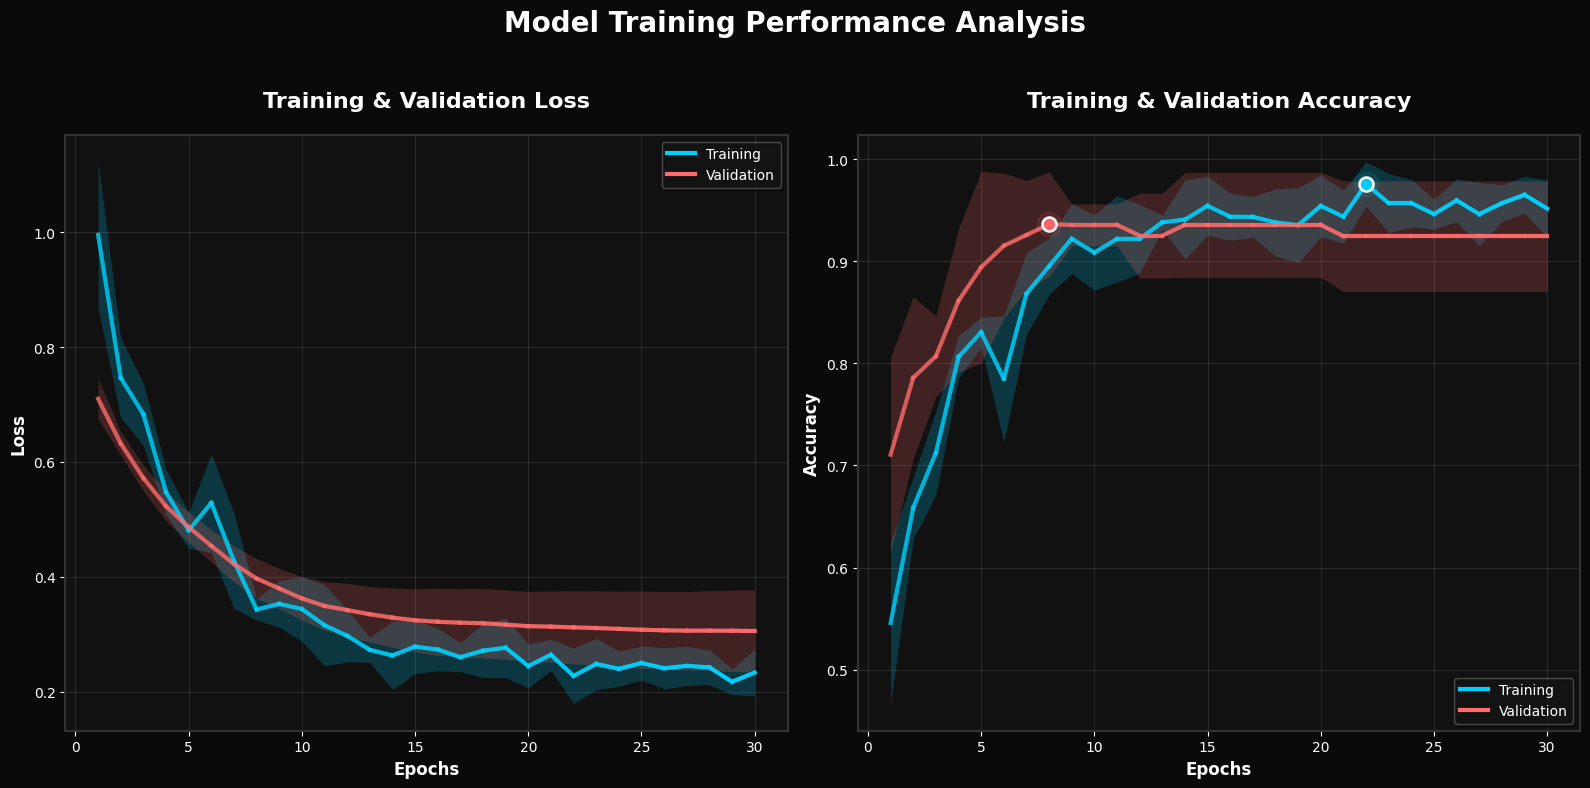


--- Proceeding with XAI explanation for the best model (F1: 1.0000) ---
Loading best model weights from: temp_model_weights/best_model_fold_1.weights.h5


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 138 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best model for XAI re-built and weights loaded.

--- Starting XAI Visualizations ---
Computing Integrated Gradients for a sample...
Computing Permutation Gene Importance (on a subset of samples, and subset of 200 genes)...
Computing permutation importance for a random subset of 200/20318 genes...
Processed 50/200 selected genes for permutation importance.
Processed 100/200 selected genes for permutation importance.
Processed 150/200 selected genes for permutation importance.
Processed 200/200 selected genes for permutation importance.
No genes had non-zero permutation importance (possibly all permuted genes had 0 impact or only a few were permuted). Skipping Permutation plot.
Computing Patch Importance (GradCAM) for a sample...
Could not automatically find a suitable layer for GradCAM on patches. Please specify target_layer_name.
Extracting 'Attention Layer Outputs' for a sample...
Extracting outputs from attention layers: ['multi_head_attention', 'multi_head_attention_1', 'v2g_attenti

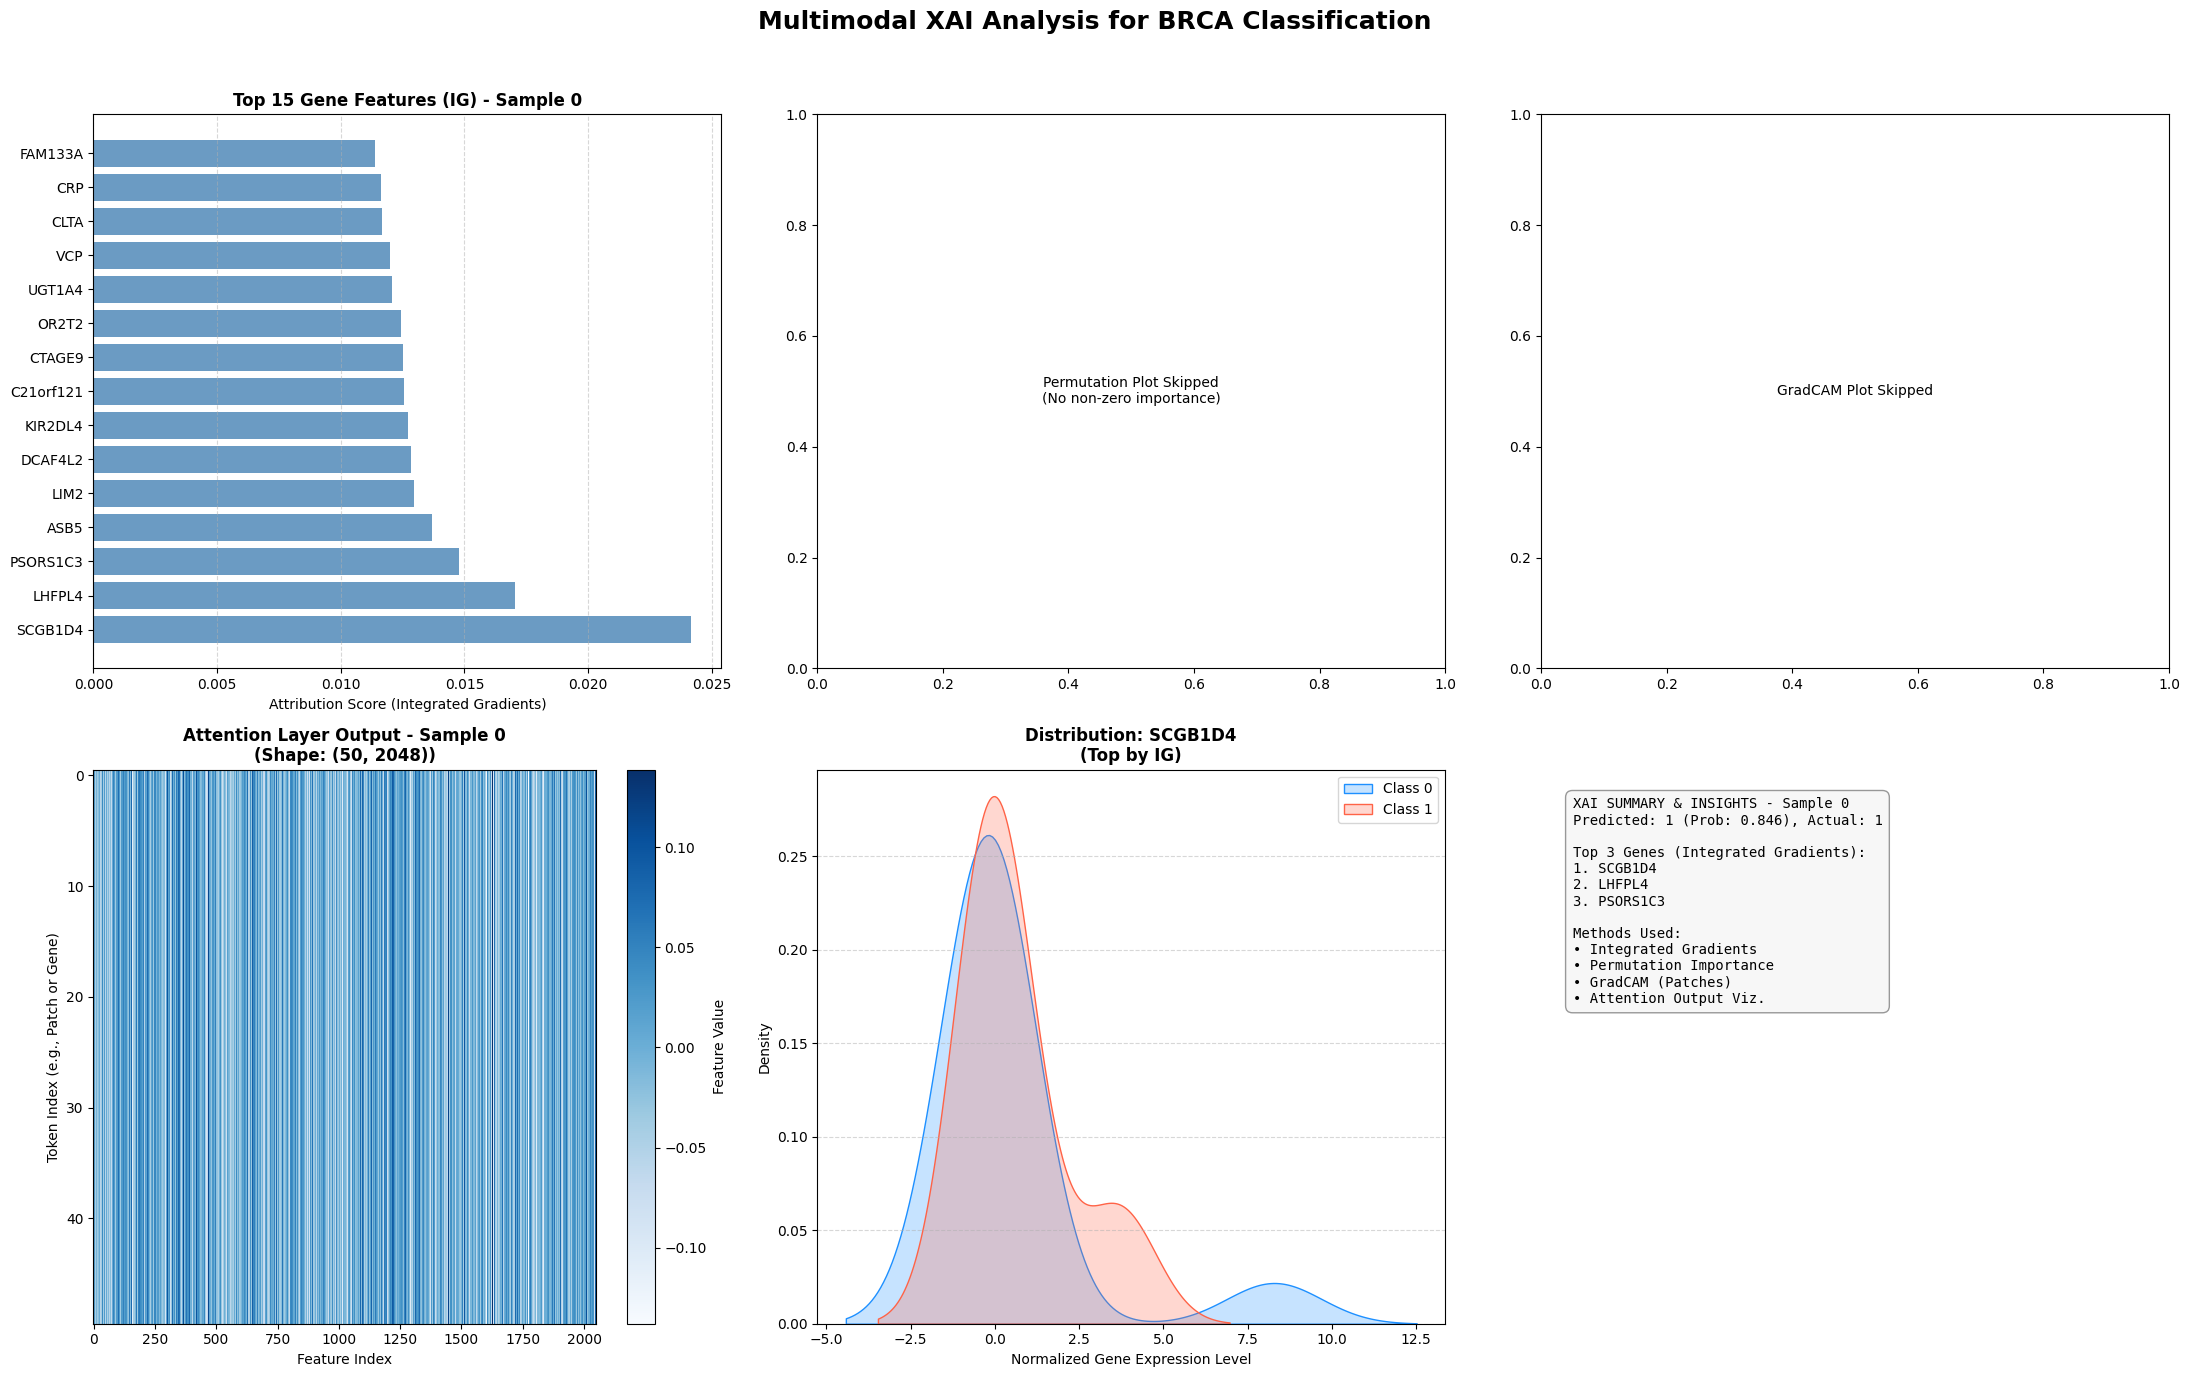

Saved permutation gene importance scores to 'gene_importance_scores_permutation.npy'
Saved IG gene attributions to 'gene_attributions_ig.npy'

XAI analysis complete! Check 'multimodal_xai_analysis_enhanced.png' for visualizations.
Cleaned up temporary weights folder: temp_model_weights

--- Script Execution Complete ---


In [14]:
# --- MAIN TRAINING PIPELINE ---
def main():
    NUM_HEADS_CONFIG = 8
    NUM_PATCHES = 50
    EPOCHS = 35
    BATCH_SIZE = 8

    metadata = preprocess_metadata(METADATA_FILE)
    print(f"Metadata preprocessing complete. Count: {len(metadata)}")
    if metadata.empty: print("Metadata empty after preprocessing. Exiting."); return

    image_data_dict, metadata = preprocess_images(IMAGE_DIR, metadata, max_patches=NUM_PATCHES)
    print(f"Image preprocessing complete. Sample count: {len(metadata)}, Image data dict keys: {len(image_data_dict)}")
    if metadata.empty or not image_data_dict: print("No samples/images after image preprocessing. Exiting."); return

    gex_data_df, metadata, labels = filter_data(GEX_FILE, metadata)
    print(f"Data filtering complete. Sample count: {len(metadata)}, GEX shape: {gex_data_df.shape}")
    if metadata.empty or gex_data_df.empty: print("No samples common to GEX and Images/Metadata. Exiting."); return

    gene_feature_names = gex_data_df.columns.tolist()

    gex_data_scaled_df = preprocess_gene_expression(gex_data_df)
    print(f"Gene expression preprocessing complete. Shape: {gex_data_scaled_df.shape}")
    if gex_data_scaled_df.empty: print("GEX data empty after preprocessing. Exiting."); return

    image_data_list_ordered = []
    final_sample_ids = metadata['Sample ID'].tolist()
    default_img_shape_h, default_img_shape_w, default_img_channels = 256, 256, 3
    if image_data_dict:
        first_key = next(iter(image_data_dict), None)
        if first_key and image_data_dict[first_key].ndim == 4:
            _, default_img_shape_h, default_img_shape_w, default_img_channels = image_data_dict[first_key].shape

    for sample_id in final_sample_ids:
        if sample_id in image_data_dict:
            image_data_list_ordered.append(image_data_dict[sample_id])
        else:
            print(f"Warning: Sample ID {sample_id} in final metadata but not in image_data_dict. Appending zeros.")
            image_data_list_ordered.append(np.zeros((NUM_PATCHES, default_img_shape_h, default_img_shape_w, default_img_channels)))

    if not image_data_list_ordered: print("Image data list empty after ordering. Exiting."); return

    print("Precomputing image features...")
    image_features = extract_image_features(image_data_list_ordered)
    print(f"Image feature extraction complete. Shape: {image_features.shape if hasattr(image_features, 'shape') else 'N/A'}")
    if not hasattr(image_features, 'shape') or image_features.ndim == 0 or image_features.shape[0] == 0:
        print("Image feature extraction resulted in empty or invalid data. Exiting."); return

    gex_data_numpy = gex_data_scaled_df.to_numpy()
    labels_numpy = labels.to_numpy()

    if not validate_data_consistency(image_features, gex_data_numpy, labels_numpy, metadata, gene_feature_names):
        print("Exiting due to data inconsistencies."); return
    labels_numpy = labels_numpy.astype(int)

    n_splits_kf = 5
    if labels_numpy.size > 0:
        unique_l, counts_l = np.unique(labels_numpy, return_counts=True)
        if len(unique_l) > 1:
            min_class_count = np.min(counts_l)
            n_splits_kf = min(n_splits_kf, min_class_count) if min_class_count > 1 else 2
        else:
            print("Warning: Only one class present in labels. StratifiedKFold might behave like KFold or error.")
            n_splits_kf = 2 if labels_numpy.size >= 2 else 1
    else:
        print("Error: Labels array is empty. Cannot proceed with KFold."); return

    if n_splits_kf < 2 and labels_numpy.size >=2 :
        print(f"Adjusted n_splits to 2 due to small class sizes. Original smallest class count: {min_class_count if 'min_class_count' in locals() else 'N/A'}")
        n_splits_kf = 2
    elif n_splits_kf < 2 :
        print("Error: Cannot perform KFold with n_splits < 2. Data too small or imbalanced."); return

    if labels_numpy.size < n_splits_kf or \
       (len(np.unique(labels_numpy)) > 1 and np.min(np.unique(labels_numpy, return_counts=True)[1]) < n_splits_kf) :
        print(f"Data too small or imbalanced for StratifiedKFold with {n_splits_kf} splits. Exiting.")
        print(f"Total samples: {labels_numpy.size}, Unique labels counts: {np.unique(labels_numpy, return_counts=True)}"); return

    skf = StratifiedKFold(n_splits=n_splits_kf, shuffle=True, random_state=42)
    all_f1_scores, all_mcc_scores, all_pr_aucs = [], [], []
    all_histories = []

    best_model_score = -1.0
    xai_data_for_best_model = {}
    temp_weights_folder = "temp_model_weights"
    os.makedirs(temp_weights_folder, exist_ok=True)

    fold = 1
    for train_index, val_index in skf.split(image_features, labels_numpy):
        print(f"\nStarting Fold {fold}/{n_splits_kf}...\n")
        if len(train_index) == 0 or len(val_index) == 0:
            print(f"Fold {fold} has empty train or validation set. Skipping."); fold +=1; continue

        x1_train, x1_val = image_features[train_index], image_features[val_index]
        x2_train, x2_val = gex_data_numpy[train_index], gex_data_numpy[val_index]
        y_train, y_val = labels_numpy[train_index], labels_numpy[val_index]

        if len(np.unique(y_val)) < 2 and len(y_val) > 0 :
             print(f"Warning: Fold {fold} validation set has only one class ({np.unique(y_val)}). Metrics like F1, MCC, PR-AUC might be ill-defined or 0.")

        tf.keras.backend.clear_session(); gc.collect()

        model = build_transformer_model(
            gene_dims=x2_train.shape[1], vision_feature_dim=x1_train.shape[2],
            num_patches=x1_train.shape[1], num_heads=NUM_HEADS_CONFIG)
        if fold == 1: model.summary(line_length=150)

        lr_callback = LearningRateScheduler(lr_scheduler)
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1, mode='min')

        history = model.fit([x1_train, x2_train], y_train, validation_data=([x1_val, x2_val], y_val),
            epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[lr_callback, early_stopping], verbose=1)
        all_histories.append(history)

        y_val_pred_probs = model.predict([x1_val, x2_val], verbose=0)
        y_val_pred = (y_val_pred_probs >= 0.5).astype(int)

        cm = confusion_matrix(y_val, y_val_pred)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)
        mcc = matthews_corrcoef(y_val, y_val_pred)
        pr_auc = 0.0
        if len(np.unique(y_val)) > 1 :
            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_probs)
            pr_auc = auc(recall, precision)

        current_score = f1
        if current_score > best_model_score:
            print(f"New best model found in Fold {fold} with F1-score: {current_score:.4f}")
            best_model_score = current_score
            current_best_model_weights_path = os.path.join(temp_weights_folder, f"best_model_fold_{fold}.weights.h5")
            model.save_weights(current_best_model_weights_path)

            best_model_construction_args = {'gene_dims': x2_train.shape[1], 'vision_feature_dim': x1_train.shape[2],
                'num_patches': x1_train.shape[1], 'num_heads': NUM_HEADS_CONFIG}

            background_size_xai = min(100, x1_train.shape[0])
            if background_size_xai > 0 :
                bg_indices_xai = np.random.choice(x1_train.shape[0], background_size_xai, replace=False)
                xai_data_for_best_model = {
                    'construction_args': best_model_construction_args,
                    'weights_path': current_best_model_weights_path,
                    'vision_to_explain': x1_val.copy(), 'gene_to_explain_np': x2_val.copy(),
                    'labels_to_explain': y_val.copy(),
                }
            else:
                print("Warning: Training data for current fold is too small for XAI background/subset. XAI may be limited.")
                xai_data_for_best_model = {}
        del model; gc.collect()
        all_f1_scores.append(f1); all_mcc_scores.append(mcc); all_pr_aucs.append(pr_auc)
        print(f"Fold {fold} Metrics: F1={f1:.4f}, MCC={mcc:.4f}, PR-AUC={pr_auc:.4f}, CM:\n{cm}")
        fold += 1

    if not all_f1_scores:
        print("No folds were successfully trained. Exiting before XAI analysis.")
        if os.path.exists(temp_weights_folder): import shutil; shutil.rmtree(temp_weights_folder)
        return

    print("\nFinal Cross-Validation Metrics (Mean ± Std):")
    print(f"Average F1-Score: {np.mean(all_f1_scores):.4f} ± {np.std(all_f1_scores):.4f}")
    print(f"Average MCC: {np.mean(all_mcc_scores):.4f} ± {np.std(all_mcc_scores):.4f}")
    print(f"Average PR-AUC: {np.mean(all_pr_aucs):.4f} ± {np.std(all_pr_aucs):.4f}")

    if all_histories: plot_training_curves(all_histories)
    else: print("No training histories recorded to plot.")

    if xai_data_for_best_model and 'weights_path' in xai_data_for_best_model:
        print(f"\n--- Proceeding with XAI explanation for the best model (F1: {best_model_score:.4f}) ---")
        print(f"Loading best model weights from: {xai_data_for_best_model['weights_path']}")
        tf.keras.backend.clear_session(); gc.collect()
        loaded_best_model = build_transformer_model(**xai_data_for_best_model['construction_args'])
        try:
            loaded_best_model.load_weights(xai_data_for_best_model['weights_path'])
            print("Best model for XAI re-built and weights loaded.")
        except Exception as e:
            print(f"Error loading weights for XAI model: {e}")
            if os.path.exists(temp_weights_folder): import shutil; shutil.rmtree(temp_weights_folder)
            return

        explainer = MultimodalExplainer(loaded_best_model, gene_feature_names)
        print("\n--- Starting XAI Visualizations ---")
        xai_results = create_publication_visualizations(
            explainer,
            xai_data_for_best_model['vision_to_explain'],
            xai_data_for_best_model['gene_to_explain_np'],
            xai_data_for_best_model['labels_to_explain'],
            gene_feature_names_list=gene_feature_names,
            sample_idx=0, top_genes=15,
            max_genes_for_permutation_viz=200 # MODIFIED: Pass the limit for permutation in viz
        )

        if xai_results:
            if 'gene_importance_perm' in xai_results and xai_results['gene_importance_perm'] is not None:
                np.save('gene_importance_scores_permutation.npy', xai_results['gene_importance_perm'])
                print("Saved permutation gene importance scores to 'gene_importance_scores_permutation.npy'")
            if 'gene_attributions_ig' in xai_results and xai_results['gene_attributions_ig'] is not None:
                np.save('gene_attributions_ig.npy', xai_results['gene_attributions_ig'])
                print("Saved IG gene attributions to 'gene_attributions_ig.npy'")
        print("\nXAI analysis complete! Check 'multimodal_xai_analysis_enhanced.png' for visualizations.")
    else:
        print("No best model data available for XAI analysis or XAI data is incomplete.")

    if os.path.exists(temp_weights_folder):
        import shutil
        try:
            shutil.rmtree(temp_weights_folder)
            print(f"Cleaned up temporary weights folder: {temp_weights_folder}")
        except Exception as e:
            print(f"Error cleaning up temp folder {temp_weights_folder}: {e}")

if __name__ == "__main__":
    main()
    print("\n--- Script Execution Complete ---")